Dataset loaded successfully!
Dataset shape: (690, 15)

X shape: (690, 14)
y values: [0 1]

X_train shape: (552, 14)
X_test shape: (138, 14)
y_train shape: (552,)
y_test shape: (138,)

=== Multi-Layer Perceptron (Neural Network) Classifier ===

✓ Model Training Completed!

MLPClassifier Train Score: 1.0
MLPClassifier Test Score: 0.7753623188405797
MLPClassifier Loss: 0.002986005410306543
MLPClassifier No. of Iterations: 127
MLPClassifier No. of Layers: 4
MLPClassifier Output Activation: logistic

Predicted Values (First 10): [1 1 1 1 1 0 0 1 0 1]
Actual Values (First 10): [1 1 0 1 1 1 1 1 0 1]

Prediction Probabilities (First 10):
[[1.64248828e-08 9.99999984e-01]
 [7.15937151e-04 9.99284063e-01]
 [1.72040675e-04 9.99827959e-01]
 [3.43106504e-06 9.99996569e-01]
 [2.26728650e-07 9.99999773e-01]
 [1.00000000e+00 4.29411667e-20]
 [9.99951114e-01 4.88862044e-05]
 [8.98451278e-07 9.99999102e-01]
 [9.97894481e-01 2.10551862e-03]
 [1.47398954e-07 9.99999853e-01]]

Confusion Matrix:
 [[58 19]
 [

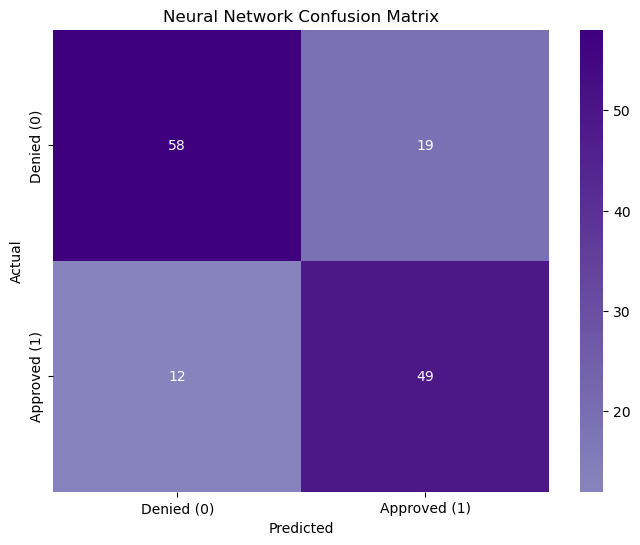


Neural Network Accuracy Score: 0.7754
Neural Network F1 Score: 0.7597

Classification Report (Neural Network):
              precision    recall  f1-score   support

      Denied       0.83      0.75      0.79        77
    Approved       0.72      0.80      0.76        61

    accuracy                           0.78       138
   macro avg       0.77      0.78      0.77       138
weighted avg       0.78      0.78      0.78       138


NEURAL NETWORK ARCHITECTURE
Input Layer: 14 neurons (features)
Hidden Layer 1: 100 neurons
Hidden Layer 2: 50 neurons
Output Layer: 2 neurons (binary classification)
Total Layers: 4

=== Testing Different Network Architectures ===
Architecture (50,): Test Accuracy = 0.7971
Architecture (100,): Test Accuracy = 0.7899
Architecture (100, 50): Test Accuracy = 0.8333
Architecture (100, 50, 25): Test Accuracy = 0.8261
Architecture (150, 100, 50): Test Accuracy = 0.8478


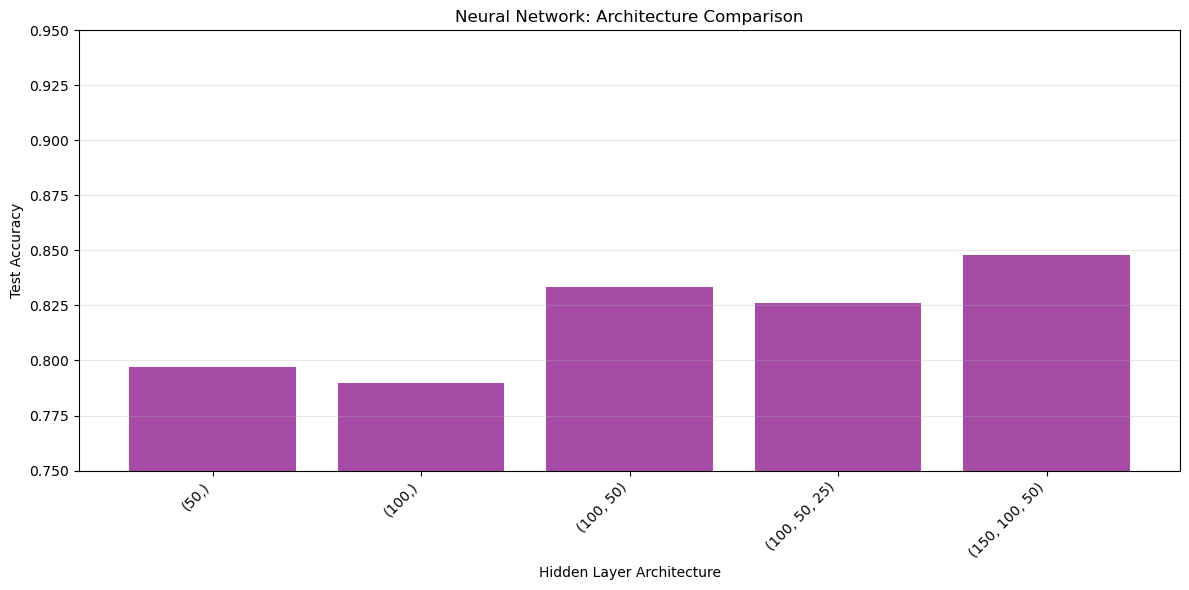


Best Architecture: (150, 100, 50) with accuracy: 0.8478

=== Testing Different Activation Functions ===
Activation "identity": Test Accuracy = 0.8188
Activation "logistic": Test Accuracy = 0.8333
Activation "tanh": Test Accuracy = 0.7971
Activation "relu": Test Accuracy = 0.8333


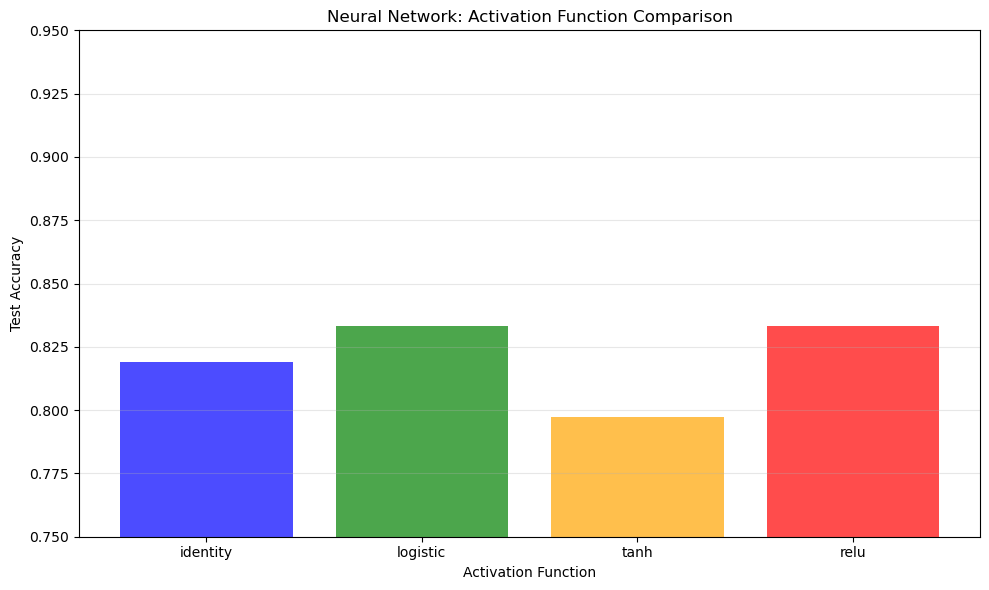


Best Activation: logistic with accuracy: 0.8333

=== Training Learning Curve ===


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_per

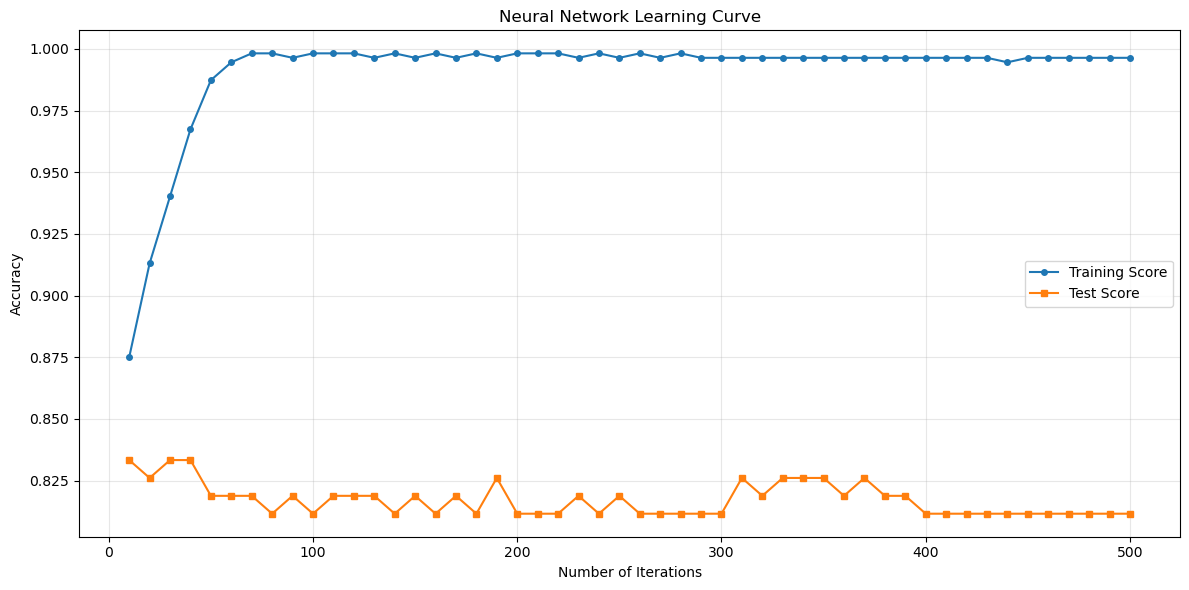

Final Training Accuracy: 0.9964
Final Test Accuracy: 0.8116

NEURAL NETWORK CLASSIFICATION SUMMARY
✓ Model: Multi-Layer Perceptron (Neural Network)
✓ Architecture: (100, 50)
✓ Activation Function: logistic
✓ Solver: lbfgs
✓ Training Accuracy: 1.0000
✓ Test Accuracy: 0.7754
✓ Number of Iterations: 127
✓ Final Loss: 0.002986


In [1]:
# Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ====================================================
# Load Australian Credit Approval Dataset
# ====================================================

# Load data from URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"
column_names = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 
                'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'target']

data = pd.read_csv(url, sep=' ', names=column_names, na_values='?')

print('Dataset loaded successfully!')
print('Dataset shape:', data.shape)

# ====================================================
# Data Preprocessing
# ====================================================

# Separate features and target
X = data.drop('target', axis=1)
y = data['target']

print('\nX shape:', X.shape)
print('y values:', y.unique())

# Handle missing values
X = X.fillna(X.median())

# Encode categorical variables if any
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Standardize features (IMPORTANT for Neural Networks!)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ====================================================
# Splitting Data
# ====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y
)

print('\n====================================================')
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)
print('====================================================')

# ====================================================
# Applying MLPClassifier Model (Neural Network)
# ====================================================

print("\n=== Multi-Layer Perceptron (Neural Network) Classifier ===\n")

'''
sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=(100,), activation='relu', solver='adam',
    alpha=0.0001, batch_size='auto', learning_rate='constant', momentum=0.9,
    learning_rate_init=0.001, power_t=0.5, max_iter=200, shuffle=True,
    random_state=None, tol=0.0001, verbose=False, warm_start=False, 
    n_iter_no_change=10, nesterovs_momentum=True, early_stopping=False, 
    validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08
)
'''

MLPClassifierModel = MLPClassifier(
    activation='logistic',      # Can be: 'identity', 'logistic', 'tanh', 'relu'
    solver='lbfgs',             # Can be: 'lbfgs', 'sgd', 'adam'
    learning_rate='constant',   # Can be: 'constant', 'invscaling', 'adaptive'
    early_stopping=False,
    alpha=0.0001,
    hidden_layer_sizes=(100, 50),  # Two hidden layers: 100 and 50 neurons
    max_iter=1000,              # Increased for better convergence
    random_state=42
)

# Train the model
MLPClassifierModel.fit(X_train, y_train)

# ====================================================
# Calculating Model Details
# ====================================================

print('✓ Model Training Completed!\n')
print('====================================================')
print('MLPClassifier Train Score:', MLPClassifierModel.score(X_train, y_train))
print('MLPClassifier Test Score:', MLPClassifierModel.score(X_test, y_test))
print('MLPClassifier Loss:', MLPClassifierModel.loss_)
print('MLPClassifier No. of Iterations:', MLPClassifierModel.n_iter_)
print('MLPClassifier No. of Layers:', MLPClassifierModel.n_layers_)
print('MLPClassifier Output Activation:', MLPClassifierModel.out_activation_)
print('====================================================')

# ====================================================
# Calculating Predictions
# ====================================================

y_pred = MLPClassifierModel.predict(X_test)
y_pred_prob = MLPClassifierModel.predict_proba(X_test)

print('\n====================================================')
print('Predicted Values (First 10):', y_pred[:10])
print('Actual Values (First 10):', y_test.values[:10])
print('\nPrediction Probabilities (First 10):')
print(y_pred_prob[:10])
print('====================================================')

# ====================================================
# Calculating Confusion Matrix
# ====================================================

CM = confusion_matrix(y_test, y_pred)
print('\n====================================================')
print('Confusion Matrix:\n', CM)
print('====================================================')

# Drawing confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(CM, annot=True, fmt='d', cmap='Purples', center=True,
            xticklabels=['Denied (0)', 'Approved (1)'],
            yticklabels=['Denied (0)', 'Approved (1)'])
plt.title('Neural Network Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ====================================================
# Performance Metrics
# ====================================================

# Accuracy Score
AccScore = accuracy_score(y_test, y_pred)
print('\nNeural Network Accuracy Score:', round(AccScore, 4))

# F1 Score
F1Score = f1_score(y_test, y_pred, average='binary')
print('Neural Network F1 Score:', round(F1Score, 4))

# Classification Report
print('\nClassification Report (Neural Network):')
print(classification_report(y_test, y_pred, 
                          target_names=['Denied', 'Approved']))

# ====================================================
# Network Architecture Visualization
# ====================================================

print('\n====================================================')
print('NEURAL NETWORK ARCHITECTURE')
print('====================================================')
print(f'Input Layer: {X_train.shape[1]} neurons (features)')
print(f'Hidden Layer 1: {MLPClassifierModel.hidden_layer_sizes[0]} neurons')
if len(MLPClassifierModel.hidden_layer_sizes) > 1:
    print(f'Hidden Layer 2: {MLPClassifierModel.hidden_layer_sizes[1]} neurons')
print(f'Output Layer: 2 neurons (binary classification)')
print(f'Total Layers: {MLPClassifierModel.n_layers_}')
print('====================================================')

# ====================================================
# Testing Different Network Architectures
# ====================================================

print('\n====================================================')
print('=== Testing Different Network Architectures ===')
print('====================================================')

architectures = [
    (50,),           # Single hidden layer with 50 neurons
    (100,),          # Single hidden layer with 100 neurons
    (100, 50),       # Two hidden layers: 100 and 50 neurons
    (100, 50, 25),   # Three hidden layers: 100, 50, and 25 neurons
    (150, 100, 50)   # Three hidden layers: 150, 100, and 50 neurons
]

arch_scores = []

for arch in architectures:
    mlp_temp = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
    mlp_temp.fit(X_train, y_train)
    score = mlp_temp.score(X_test, y_test)
    arch_scores.append(score)
    print(f'Architecture {arch}: Test Accuracy = {score:.4f}')

# Plot architecture comparison
plt.figure(figsize=(12, 6))
arch_labels = [str(arch) for arch in architectures]
plt.bar(arch_labels, arch_scores, color='purple', alpha=0.7)
plt.xlabel('Hidden Layer Architecture')
plt.ylabel('Test Accuracy')
plt.title('Neural Network: Architecture Comparison')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.75, 0.95])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n====================================================')
best_idx = arch_scores.index(max(arch_scores))
print(f'Best Architecture: {architectures[best_idx]} with accuracy: {max(arch_scores):.4f}')
print('====================================================')

# ====================================================
# Testing Different Activation Functions
# ====================================================

print('\n====================================================')
print('=== Testing Different Activation Functions ===')
print('====================================================')

activations = ['identity', 'logistic', 'tanh', 'relu']
activation_scores = []

for activation in activations:
    mlp_temp = MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation=activation,
        solver='adam',
        max_iter=1000,
        random_state=42
    )
    mlp_temp.fit(X_train, y_train)
    score = mlp_temp.score(X_test, y_test)
    activation_scores.append(score)
    print(f'Activation "{activation}": Test Accuracy = {score:.4f}')

# Plot activation function comparison
plt.figure(figsize=(10, 6))
plt.bar(activations, activation_scores, color=['blue', 'green', 'orange', 'red'], alpha=0.7)
plt.xlabel('Activation Function')
plt.ylabel('Test Accuracy')
plt.title('Neural Network: Activation Function Comparison')
plt.ylim([0.75, 0.95])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n====================================================')
best_activation_idx = activation_scores.index(max(activation_scores))
print(f'Best Activation: {activations[best_activation_idx]} with accuracy: {max(activation_scores):.4f}')
print('====================================================')

# ====================================================
# Learning Curve
# ====================================================

print('\n====================================================')
print('=== Training Learning Curve ===')
print('====================================================')

# Train model with verbose to track iterations
mlp_learning = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    warm_start=True
)

train_scores = []
test_scores = []
iterations = range(10, 501, 10)

for max_iter in iterations:
    mlp_learning.max_iter = max_iter
    mlp_learning.fit(X_train, y_train)
    train_scores.append(mlp_learning.score(X_train, y_train))
    test_scores.append(mlp_learning.score(X_test, y_test))

# Plot learning curve
plt.figure(figsize=(12, 6))
plt.plot(iterations, train_scores, label='Training Score', marker='o', markersize=4)
plt.plot(iterations, test_scores, label='Test Score', marker='s', markersize=4)
plt.xlabel('Number of Iterations')
plt.ylabel('Accuracy')
plt.title('Neural Network Learning Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final Training Accuracy: {train_scores[-1]:.4f}')
print(f'Final Test Accuracy: {test_scores[-1]:.4f}')
print('====================================================')

# ====================================================
# Final Summary
# ====================================================

print('\n' + '='*60)
print('NEURAL NETWORK CLASSIFICATION SUMMARY')
print('='*60)
print(f'✓ Model: Multi-Layer Perceptron (Neural Network)')
print(f'✓ Architecture: {MLPClassifierModel.hidden_layer_sizes}')
print(f'✓ Activation Function: {MLPClassifierModel.activation}')
print(f'✓ Solver: {MLPClassifierModel.solver}')
print(f'✓ Training Accuracy: {MLPClassifierModel.score(X_train, y_train):.4f}')
print(f'✓ Test Accuracy: {MLPClassifierModel.score(X_test, y_test):.4f}')
print(f'✓ Number of Iterations: {MLPClassifierModel.n_iter_}')
print(f'✓ Final Loss: {MLPClassifierModel.loss_:.6f}')
print('='*60)


Dataset loaded successfully!
Dataset shape: (690, 15)
First 5 rows:
    A1     A2     A3  A4  A5  A6     A7  A8  A9  A10  A11  A12  A13   A14  \
0   1  22.08  11.46   2   4   4  1.585   0   0    0    1    2  100  1213   
1   0  22.67   7.00   2   8   4  0.165   0   0    0    0    2  160     1   
2   0  29.58   1.75   1   4   4  1.250   0   0    0    1    2  280     1   
3   0  21.67  11.50   1   5   3  0.000   1   1   11    1    2    0     1   
4   1  20.17   8.17   2   6   4  1.960   1   1   14    0    2   60   159   

   target  
0       0  
1       0  
2       0  
3       1  
4       1  

X Data shape: (690, 14)
y Data shape: (690,)
Target values: [0 1]

X_train shape is: (552, 14)
X_test shape is: (138, 14)
y_train shape is: (552,)
y_test shape is: (138,)

=== K-Nearest Neighbors (KNN) Classifier ===

KNN Train Score (Accuracy): 0.8858695652173914
KNN Test Score (Accuracy): 0.8043478260869565

Predicted Values (First 10): [1 1 0 1 1 0 0 1 0 1]
Actual Values (First 10): [1 1 0 1 1 1

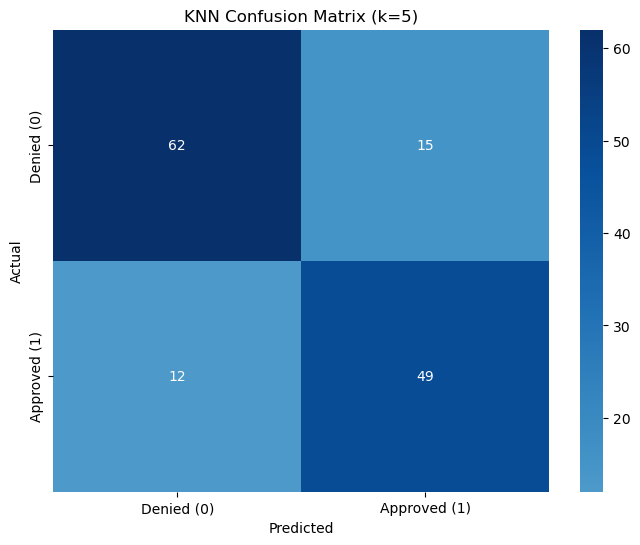


KNN Accuracy Score: 0.8043
KNN F1 Score: 0.784

Classification Report (KNN):
              precision    recall  f1-score   support

      Denied       0.84      0.81      0.82        77
    Approved       0.77      0.80      0.78        61

    accuracy                           0.80       138
   macro avg       0.80      0.80      0.80       138
weighted avg       0.81      0.80      0.80       138


=== Testing Different K Values ===
K = 3: Test Accuracy = 0.8043
K = 5: Test Accuracy = 0.8043
K = 7: Test Accuracy = 0.8406
K = 9: Test Accuracy = 0.8406
K = 11: Test Accuracy = 0.8551


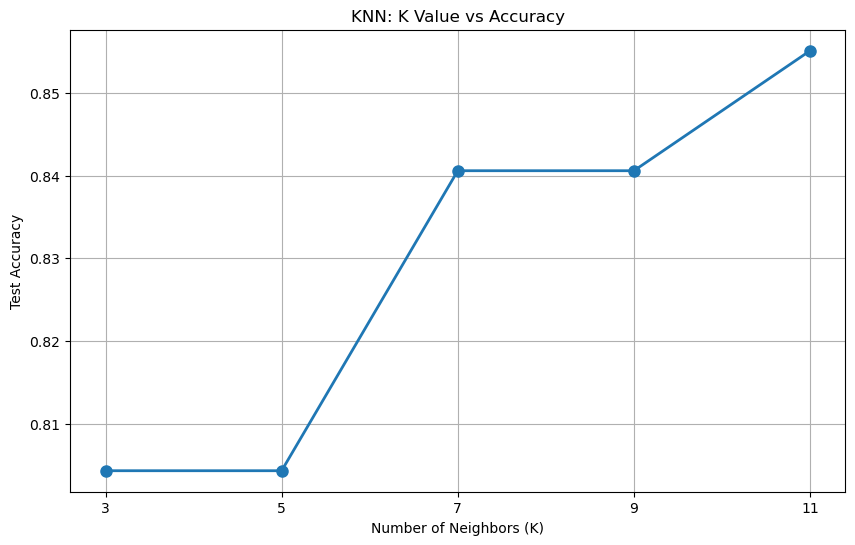


Best K value: 11 with accuracy: 0.8551


In [3]:
# Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ====================================================
# Load Australian Credit Approval Dataset
# ====================================================

# Method 1: Using direct URL (No installation needed)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"
column_names = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 
                'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'target']

# Load data
data = pd.read_csv(url, sep=' ', names=column_names, na_values='?')

print('Dataset loaded successfully!')
print('Dataset shape:', data.shape)
print('First 5 rows:\n', data.head())

# ====================================================
# Data Preprocessing
# ====================================================

# Separate features and target
X = data.drop('target', axis=1)
y = data['target']

print('\nX Data shape:', X.shape)
print('y Data shape:', y.shape)
print('Target values:', y.unique())

# Handle missing values
X = X.fillna(X.median())

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=[np.number]).columns

# Encode categorical variables if any
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Standardize features (Important for KNN!)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ====================================================
# Splitting Data
# ====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y
)

# Splitted Data
print('\n====================================================')
print('X_train shape is:', X_train.shape)
print('X_test shape is:', X_test.shape)
print('y_train shape is:', y_train.shape)
print('y_test shape is:', y_test.shape)
print('====================================================')

# ====================================================
# Applying KNeighborsClassifier Model
# ====================================================

print("\n=== K-Nearest Neighbors (KNN) Classifier ===\n")

'''
sklearn.neighbors.KNeighborsClassifier(
    n_neighbors=5, weights='uniform', algorithm='auto', 
    leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None
)
'''

KNNClassifierModel = KNeighborsClassifier(
    n_neighbors=5,          # Number of neighbors (you can try 3, 5, 7)
    weights='uniform',      # Can be 'uniform' or 'distance'
    algorithm='auto'        # Can be 'ball_tree', 'kd_tree', 'brute'
)

# Train the model
KNNClassifierModel.fit(X_train, y_train)

# Calculating Performance
print('KNN Train Score (Accuracy):', KNNClassifierModel.score(X_train, y_train))
print('KNN Test Score (Accuracy):', KNNClassifierModel.score(X_test, y_test))
print('====================================================')

# ====================================================
# Calculating Prediction
# ====================================================

y_pred = KNNClassifierModel.predict(X_test)
y_pred_prob = KNNClassifierModel.predict_proba(X_test)

print('\nPredicted Values (First 10):', y_pred[:10])
print('Actual Values (First 10):', y_test.values[:10])
print('\nPrediction Probabilities (First 10):')
print(y_pred_prob[:10])

# ====================================================
# Calculating Confusion Matrix
# ====================================================

CM = confusion_matrix(y_test, y_pred)
print('\n====================================================')
print('Confusion Matrix:\n', CM)
print('====================================================')

# Drawing confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(CM, annot=True, fmt='d', cmap='Blues', center=True,
            xticklabels=['Denied (0)', 'Approved (1)'],
            yticklabels=['Denied (0)', 'Approved (1)'])
plt.title('KNN Confusion Matrix (k=5)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ====================================================
# Performance Metrics
# ====================================================

# Accuracy Score
AccScore = accuracy_score(y_test, y_pred)
print('\nKNN Accuracy Score:', round(AccScore, 4))

# F1 Score
F1Score = f1_score(y_test, y_pred, average='binary')
print('KNN F1 Score:', round(F1Score, 4))

# Classification Report
print('\nClassification Report (KNN):')
print(classification_report(y_test, y_pred, 
                          target_names=['Denied', 'Approved']))

# ====================================================
# Testing Different K Values
# ====================================================

print('\n====================================================')
print('=== Testing Different K Values ===')
print('====================================================')

k_values = [3, 5, 7, 9, 11]
k_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    score = knn_temp.score(X_test, y_test)
    k_scores.append(score)
    print(f'K = {k}: Test Accuracy = {score:.4f}')

# Plot K values vs Accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, k_scores, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.title('KNN: K Value vs Accuracy')
plt.grid(True)
plt.xticks(k_values)
plt.show()

print('\n====================================================')
print(f'Best K value: {k_values[k_scores.index(max(k_scores))]} with accuracy: {max(k_scores):.4f}')
print('====================================================')

Training samples: 552
Testing samples: 138

=== Support Vector Machine (SVM) with RBF Kernel ===

SVM Train Score (Accuracy):  0.9094202898550725
SVM Test Score (Accuracy):  0.8115942028985508
Predicted Values (First 10):  [1 1 1 1 1 0 1 1 0 1]
Actual Values (First 10):  [1 1 0 1 1 1 1 1 0 1]

Confusion Matrix:
 [[55 22]
 [ 4 57]]


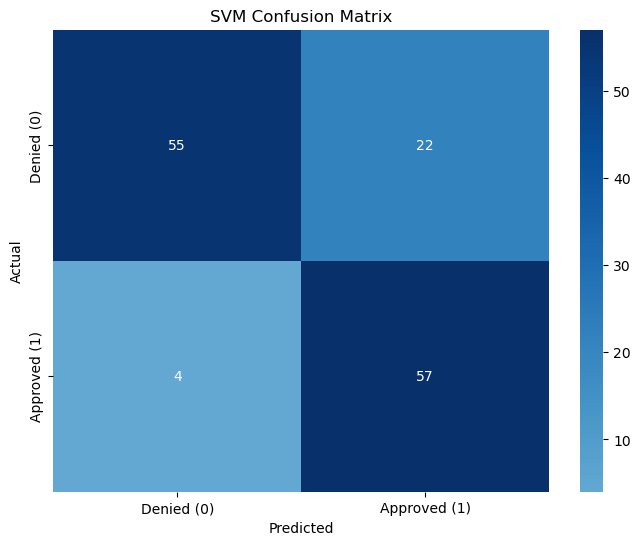


SVM Accuracy Score:  0.8116
SVM F1 Score:  0.8143

Classification Report (SVM):
              precision    recall  f1-score   support

      Denied       0.93      0.71      0.81        77
    Approved       0.72      0.93      0.81        61

    accuracy                           0.81       138
   macro avg       0.83      0.82      0.81       138
weighted avg       0.84      0.81      0.81       138



=== Logistic Regression Model ===

Logistic Regression Train Score:  0.8913043478260869
Logistic Regression Test Score:  0.8333333333333334
Predicted Values (First 10):  [1 1 1 1 1 0 1 1 0 1]
Actual Values (First 10):  [1 1 0 1 1 1 1 1 0 1]

Confusion Matrix:
 [[58 19]
 [ 4 57]]


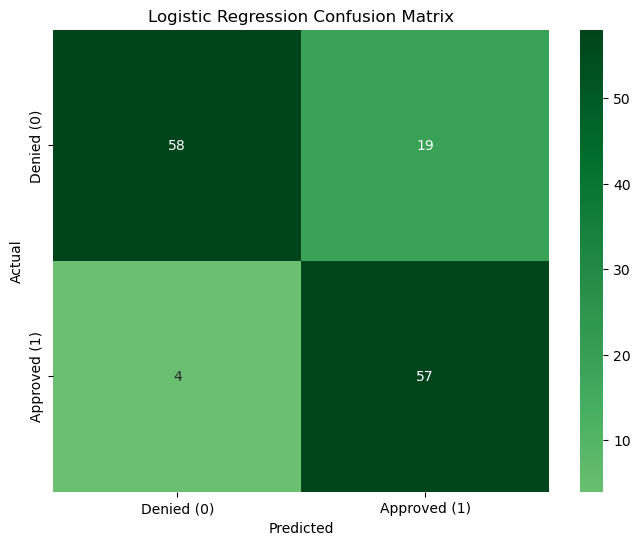


Logistic Regression Accuracy Score:  0.8333
Logistic Regression F1 Score:  0.8321

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

      Denied       0.94      0.75      0.83        77
    Approved       0.75      0.93      0.83        61

    accuracy                           0.83       138
   macro avg       0.84      0.84      0.83       138
weighted avg       0.85      0.83      0.83       138


=== MODEL COMPARISON SUMMARY ===
Model                     Accuracy     F1-Score    
--------------------------------------------------
SVM (RBF)                 0.8116       0.8143      
Logistic Regression       0.8333       0.8321      


In [4]:
# Import Libraries
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ====================================================
# Load Australian Credit Approval Dataset
# ====================================================

# Fetch dataset from UCI repository
statlog_australian_credit_approval = fetch_ucirepo(id=143)

# Data (as pandas dataframes)
X = statlog_australian_credit_approval.data.features
y = statlog_australian_credit_approval.data.targets

# ====================================================
# Data Preprocessing
# ====================================================

# Handle missing values
# Replace '?' with NaN for proper handling
X = X.replace('?', np.nan)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=[np.number]).columns

# Fill missing values
# For numerical: use median
for col in numerical_cols:
    if X[col].isnull().any():
        X[col].fillna(X[col].median(), inplace=True)

# For categorical: use mode
for col in categorical_cols:
    if X[col].isnull().any():
        X[col].fillna(X[col].mode()[0], inplace=True)

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Convert target to numpy array and flatten
y = y.values.ravel()

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ====================================================
# Splitting Data
# ====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print('====================================================')

# ====================================================
# Applying SVM Model with RBF Kernel
# ====================================================

print("\n=== Support Vector Machine (SVM) with RBF Kernel ===\n")

SVCModel = SVC(
    kernel='rbf',      # RBF kernel for non-linear classification
    C=1.0,             # Regularization parameter
    gamma='scale',     # Kernel coefficient
    max_iter=1000,
    random_state=42
)

# Train the model
SVCModel.fit(X_train, y_train)

# Calculating Performance
print('SVM Train Score (Accuracy): ', SVCModel.score(X_train, y_train))
print('SVM Test Score (Accuracy): ', SVCModel.score(X_test, y_test))
print('====================================================')

# Predictions
y_pred_svm = SVCModel.predict(X_test)
print('Predicted Values (First 10): ', y_pred_svm[:10])
print('Actual Values (First 10): ', y_test[:10])

# ====================================================
# Confusion Matrix for SVM
# ====================================================

CM_svm = confusion_matrix(y_test, y_pred_svm)
print('\nConfusion Matrix:\n', CM_svm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(CM_svm, annot=True, fmt='d', cmap='Blues', center=True,
            xticklabels=['Denied (0)', 'Approved (1)'],
            yticklabels=['Denied (0)', 'Approved (1)'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ====================================================
# Performance Metrics for SVM
# ====================================================

# Accuracy Score
AccScore_svm = accuracy_score(y_test, y_pred_svm)
print('\nSVM Accuracy Score: ', round(AccScore_svm, 4))

# F1 Score
F1Score_svm = f1_score(y_test, y_pred_svm, average='binary')
print('SVM F1 Score: ', round(F1Score_svm, 4))

# Classification Report
print('\nClassification Report (SVM):')
print(classification_report(y_test, y_pred_svm, 
                          target_names=['Denied', 'Approved']))

print('\n====================================================')
print('====================================================\n')

# ====================================================
# Applying Logistic Regression Model
# ====================================================

from sklearn.linear_model import LogisticRegression

print("=== Logistic Regression Model ===\n")

LogisticRegressionModel = LogisticRegression(
    solver='lbfgs',      # Solver for optimization
    max_iter=1000,
    random_state=42
)

# Train the model
LogisticRegressionModel.fit(X_train, y_train)

# Calculating Performance
print('Logistic Regression Train Score: ', 
      LogisticRegressionModel.score(X_train, y_train))
print('Logistic Regression Test Score: ', 
      LogisticRegressionModel.score(X_test, y_test))
print('====================================================')

# Predictions
y_pred_lr = LogisticRegressionModel.predict(X_test)
print('Predicted Values (First 10): ', y_pred_lr[:10])
print('Actual Values (First 10): ', y_test[:10])

# ====================================================
# Confusion Matrix for Logistic Regression
# ====================================================

CM_lr = confusion_matrix(y_test, y_pred_lr)
print('\nConfusion Matrix:\n', CM_lr)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(CM_lr, annot=True, fmt='d', cmap='Greens', center=True,
            xticklabels=['Denied (0)', 'Approved (1)'],
            yticklabels=['Denied (0)', 'Approved (1)'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ====================================================
# Performance Metrics for Logistic Regression
# ====================================================

# Accuracy Score
AccScore_lr = accuracy_score(y_test, y_pred_lr)
print('\nLogistic Regression Accuracy Score: ', round(AccScore_lr, 4))

# F1 Score
F1Score_lr = f1_score(y_test, y_pred_lr, average='binary')
print('Logistic Regression F1 Score: ', round(F1Score_lr, 4))

# Classification Report
print('\nClassification Report (Logistic Regression):')
print(classification_report(y_test, y_pred_lr, 
                          target_names=['Denied', 'Approved']))

# ====================================================
# Model Comparison Summary
# ====================================================

print('\n====================================================')
print('=== MODEL COMPARISON SUMMARY ===')
print('====================================================')
print(f"{'Model':<25} {'Accuracy':<12} {'F1-Score':<12}")
print('-' * 50)
print(f"{'SVM (RBF)':<25} {AccScore_svm:<12.4f} {F1Score_svm:<12.4f}")
print(f"{'Logistic Regression':<25} {AccScore_lr:<12.4f} {F1Score_lr:<12.4f}")
print('====================================================')

Dataset loaded successfully!
Dataset shape: (690, 15)

X_train shape: (552, 14)
X_test shape: (138, 14)

=== Random Forest Classifier (Bagging) ===

✓ Model Training Completed!
Random Forest Train Score: 0.980072463768116
Random Forest Test Score: 0.8260869565217391
Number of Trees: 100

Feature Importances:
   Feature  Importance
7       A8    0.335460
9      A10    0.110470
6       A7    0.087862
13     A14    0.076699
2       A3    0.071025
4       A5    0.066755
12     A13    0.064863
1       A2    0.064514
8       A9    0.049130
5       A6    0.026135
11     A12    0.015750
3       A4    0.014235
0       A1    0.008767
10     A11    0.008335

Predicted Values (First 10): [1 1 1 1 1 0 1 1 0 1]
Actual Values (First 10): [1 1 0 1 1 1 1 1 0 1]

Prediction Probabilities (First 10):
[[0.02459524 0.97540476]
 [0.22307792 0.77692208]
 [0.32645779 0.67354221]
 [0.26021032 0.73978968]
 [0.11852778 0.88147222]
 [0.74852381 0.25147619]
 [0.37928571 0.62071429]
 [0.11091667 0.88908333]
 [0.861

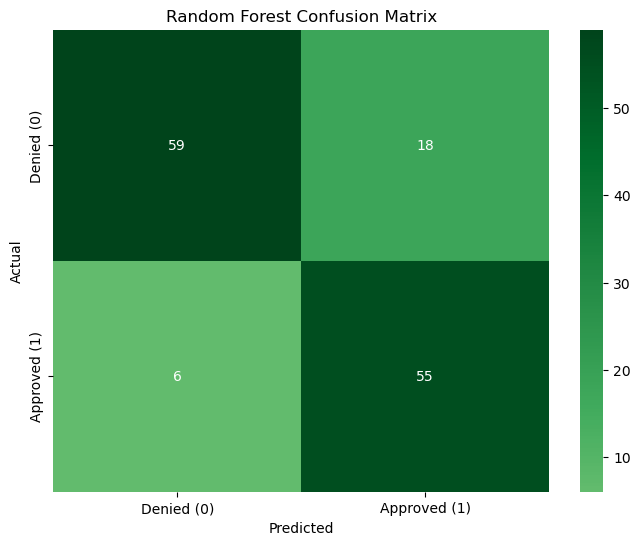


Random Forest Accuracy Score: 0.8261
Random Forest F1 Score: 0.8209

Classification Report:
              precision    recall  f1-score   support

      Denied       0.91      0.77      0.83        77
    Approved       0.75      0.90      0.82        61

    accuracy                           0.83       138
   macro avg       0.83      0.83      0.83       138
weighted avg       0.84      0.83      0.83       138



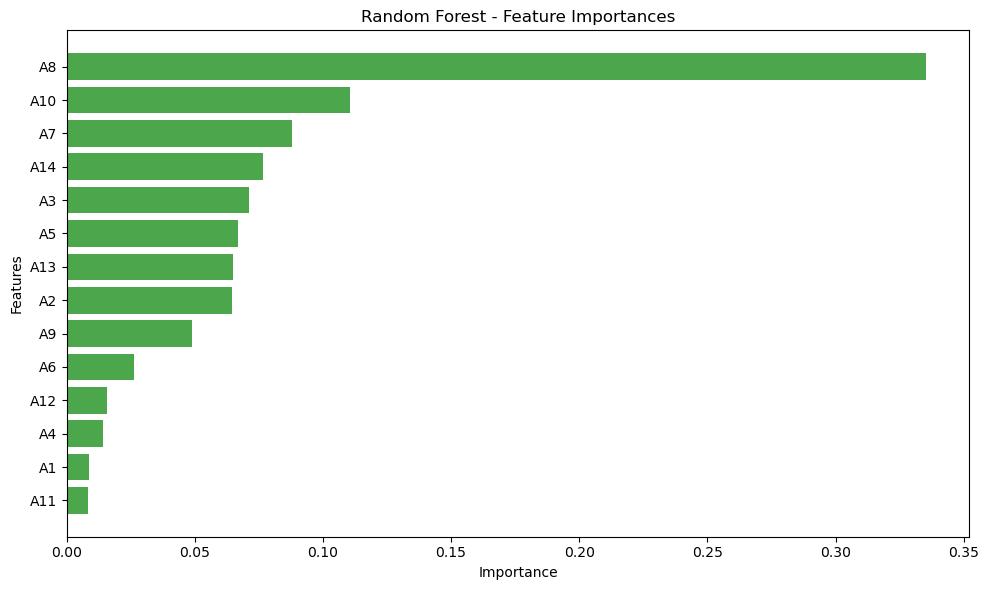


=== Testing Different Number of Trees ===
n_estimators = 50: Test Accuracy = 0.8261
n_estimators = 100: Test Accuracy = 0.8043
n_estimators = 150: Test Accuracy = 0.8116
n_estimators = 200: Test Accuracy = 0.8043
n_estimators = 250: Test Accuracy = 0.8116


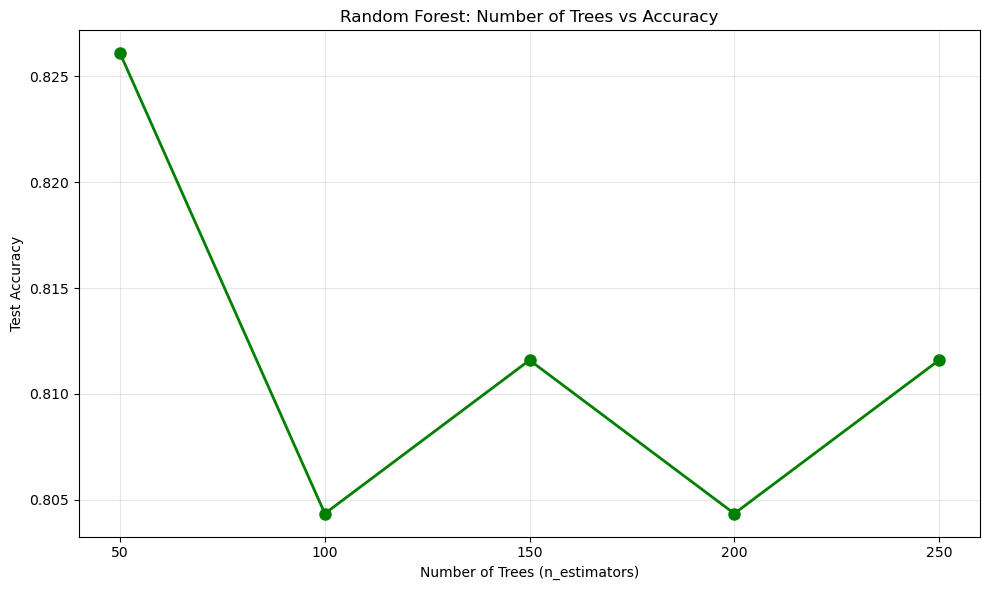


Best n_estimators: 50 with accuracy: 0.8261

=== Out-of-Bag (OOB) Score ===
OOB Score: 0.8877
Test Score: 0.8043

✅ Random Forest (Bagging) Analysis Complete!


In [1]:
# ============================================================
# RANDOM FOREST - BOOTSTRAP AGGREGATING (BAGGING)
# Australian Credit Approval Dataset
# ============================================================

# Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# Load Dataset
# ============================================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"
column_names = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 
                'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'target']

data = pd.read_csv(url, sep=' ', names=column_names, na_values='?')

print('Dataset loaded successfully!')
print('Dataset shape:', data.shape)

# ============================================================
# Data Preprocessing
# ============================================================

X = data.drop('target', axis=1)
y = data['target']

# Handle missing values
X = X.fillna(X.median())

# Encode categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('\n====================================================')
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('====================================================')

# ============================================================
# Random Forest Classifier (Bagging)
# ============================================================

print("\n=== Random Forest Classifier (Bagging) ===\n")

'''
ensemble.RandomForestClassifier(
    n_estimators=100,          # Number of trees
    criterion='gini',          # Split criterion
    max_depth=None,            # Maximum depth
    min_samples_split=2,       # Min samples to split
    bootstrap=True,            # Use bootstrap sampling (Bagging)
    random_state=42
)
'''

# Create Random Forest Model
RandomForestModel = RandomForestClassifier(
    n_estimators=100,          # 100 decision trees
    criterion='gini',          # Gini impurity
    max_depth=15,              # Max tree depth
    min_samples_split=5,       # Min samples to split node
    bootstrap=True,            # Bootstrap Aggregating (Bagging)
    random_state=42,
    n_jobs=-1                  # Use all processors
)

# Train the model
RandomForestModel.fit(X_train, y_train)

# Model Details
print('✓ Model Training Completed!')
print('====================================================')
print('Random Forest Train Score:', RandomForestModel.score(X_train, y_train))
print('Random Forest Test Score:', RandomForestModel.score(X_test, y_test))
print('Number of Trees:', RandomForestModel.n_estimators)
print('====================================================')

# ============================================================
# Feature Importances
# ============================================================

print('\nFeature Importances:')
feature_names = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 
                 'A9', 'A10', 'A11', 'A12', 'A13', 'A14']
importances = RandomForestModel.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

# ============================================================
# Predictions
# ============================================================

y_pred = RandomForestModel.predict(X_test)
y_pred_prob = RandomForestModel.predict_proba(X_test)

print('\n====================================================')
print('Predicted Values (First 10):', y_pred[:10])
print('Actual Values (First 10):', y_test.values[:10])
print('\nPrediction Probabilities (First 10):')
print(y_pred_prob[:10])
print('====================================================')

# ============================================================
# Confusion Matrix
# ============================================================

CM = confusion_matrix(y_test, y_pred)
print('\n====================================================')
print('Confusion Matrix:\n', CM)
print('====================================================')

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(CM, annot=True, fmt='d', cmap='Greens', center=True,
            xticklabels=['Denied (0)', 'Approved (1)'],
            yticklabels=['Denied (0)', 'Approved (1)'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ============================================================
# Performance Metrics
# ============================================================

AccScore = accuracy_score(y_test, y_pred)
print('\nRandom Forest Accuracy Score:', round(AccScore, 4))

F1Score = f1_score(y_test, y_pred, average='binary')
print('Random Forest F1 Score:', round(F1Score, 4))

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Denied', 'Approved']))

# ============================================================
# Plot Feature Importances
# ============================================================

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='green', alpha=0.7)
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Random Forest - Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================
# Testing Different Number of Trees
# ============================================================

print('\n====================================================')
print('=== Testing Different Number of Trees ===')
print('====================================================')

n_estimators_list = [50, 100, 150, 200, 250]
scores = []

for n_est in n_estimators_list:
    rf_temp = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)
    score = rf_temp.score(X_test, y_test)
    scores.append(score)
    print(f'n_estimators = {n_est}: Test Accuracy = {score:.4f}')

# Plot
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, scores, marker='o', linewidth=2, markersize=8, color='green')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Test Accuracy')
plt.title('Random Forest: Number of Trees vs Accuracy')
plt.grid(True, alpha=0.3)
plt.xticks(n_estimators_list)
plt.tight_layout()
plt.show()

print('\n====================================================')
print(f'Best n_estimators: {n_estimators_list[scores.index(max(scores))]} with accuracy: {max(scores):.4f}')
print('====================================================')

# ============================================================
# Out-of-Bag (OOB) Score
# ============================================================

print('\n=== Out-of-Bag (OOB) Score ===')

RandomForestOOBModel = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

RandomForestOOBModel.fit(X_train, y_train)

print(f'OOB Score: {RandomForestOOBModel.oob_score_:.4f}')
print(f'Test Score: {RandomForestOOBModel.score(X_test, y_test):.4f}')
print('====================================================')

print('\n✅ Random Forest (Bagging) Analysis Complete!')


C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

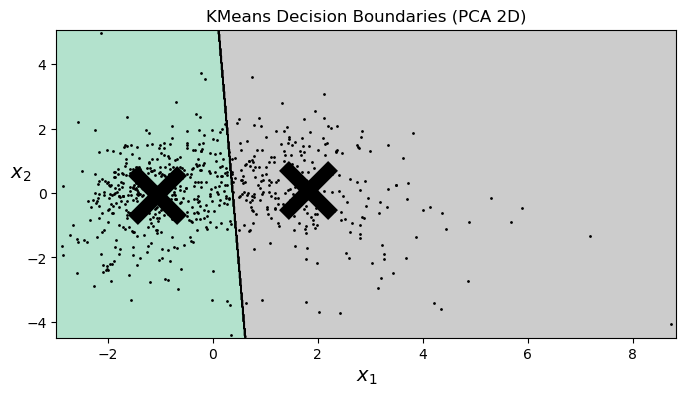

Confusion Matrix:
 [[350  33]
 [ 87 220]]


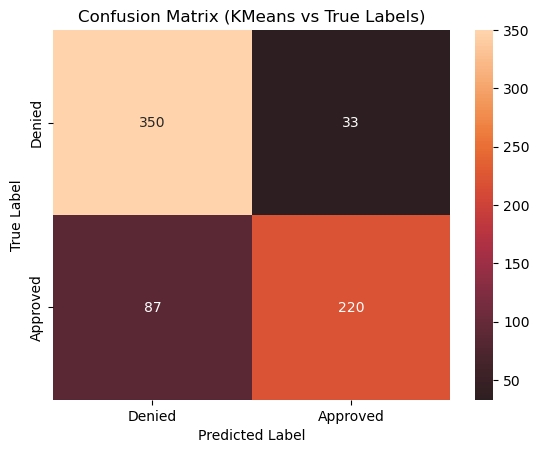

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ------------------------------
# 1) LOAD DATASET
# ------------------------------
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"
data = pd.read_csv(url, header=None, sep=r"\s+")

X_full = data.iloc[:, :-1].values   # features
y_true = data.iloc[:, -1].values   # class labels (0 = Denied, 1 = Approved)

# ------------------------------
# 2) SCALE + PCA (2D)
# ------------------------------
X_scaled = StandardScaler().fit_transform(X_full)
X = PCA(n_components=2, random_state=7).fit_transform(X_scaled)

# ------------------------------
# 3) PLOTTING FUNCTIONS (UNCHANGED)
# ------------------------------
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=30, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=50, linewidths=50,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                 cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

# ------------------------------
# 4) TRAIN KMEANS + PLOT
# ------------------------------
kmeans = KMeans(n_clusters=2, random_state=7, n_init=10)
kmeans.fit(X)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.title("KMeans Decision Boundaries (PCA 2D)")
plt.show()

# ------------------------------
# 5) CONFUSION MATRIX (APPROVED / DENIED)
# ------------------------------

# KMeans cluster labels
clusters = kmeans.labels_

# Map clusters → class labels
# (choose the mapping that gives higher accuracy)
mapping_0 = np.where(clusters == 0, 0, 1)
mapping_1 = np.where(clusters == 0, 1, 0)

cm0 = confusion_matrix(y_true, mapping_0)
cm1 = confusion_matrix(y_true, mapping_1)

CM = cm0 if cm0.trace() > cm1.trace() else cm1

print("Confusion Matrix:\n", CM)

# Draw confusion matrix
sns.heatmap(
    CM,
    annot=True,
    fmt="d",
    center=True,
    xticklabels=["Denied", "Approved"],
    yticklabels=["Denied", "Approved"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (KMeans vs True Labels)")
plt.show()

DecisionTreeClassifierModel Train Score is :  0.8636363636363636
DecisionTreeClassifierModel Test Score is :  0.8464912280701754
DecisionTreeClassifierModel Classes are :  [0 1]
DecisionTreeClassifierModel feature importances are :  [0.         0.         0.06991319 0.03616089 0.02779146 0.
 0.01618211 0.70913173 0.         0.04074988 0.         0.
 0.         0.10007074]
----------------------------------------------------
Predicted Value for DecisionTreeClassifierModel is :  [1 1 0 1 0 1 1 1 1 1]
Prediction Probabilities Value for DecisionTreeClassifierModel is :  [[0.         1.        ]
 [0.06666667 0.93333333]
 [0.96907216 0.03092784]
 [0.40517241 0.59482759]
 [0.96907216 0.03092784]
 [0.08163265 0.91836735]
 [0.08163265 0.91836735]
 [0.         1.        ]
 [0.40517241 0.59482759]
 [0.40517241 0.59482759]]
Confusion Matrix is : 
 [[101  31]
 [  4  92]]
False Positives: 31


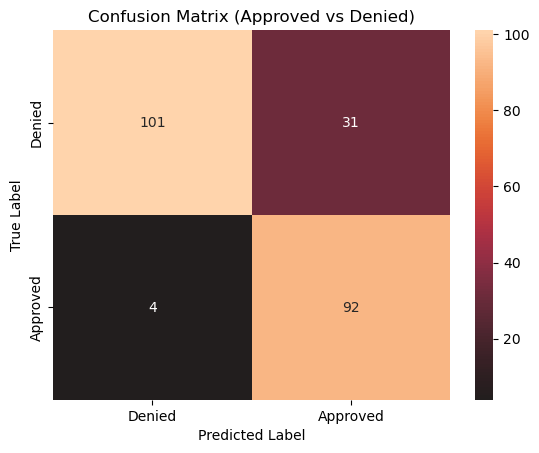

In [5]:
# Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Load Australian Credit Approval dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"
data = pd.read_csv(url, header=None, sep=r"\s+")

# X Data (features)
X = data.iloc[:, :-1].values

# y Data (class label)
y = data.iloc[:, -1].values

# ----------------------------------------------------
# Splitting data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=44, shuffle=True
)

# ----------------------------------------------------
# Applying DecisionTreeClassifier Model

DecisionTreeClassifierModel = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=33
)

DecisionTreeClassifierModel.fit(X_train, y_train)

# Calculating Details
print('DecisionTreeClassifierModel Train Score is : ',
      DecisionTreeClassifierModel.score(X_train, y_train))
print('DecisionTreeClassifierModel Test Score is : ',
      DecisionTreeClassifierModel.score(X_test, y_test))
print('DecisionTreeClassifierModel Classes are : ',
      DecisionTreeClassifierModel.classes_)
print('DecisionTreeClassifierModel feature importances are : ',
      DecisionTreeClassifierModel.feature_importances_)
print('----------------------------------------------------')

# ----------------------------------------------------
# Calculating Prediction

y_pred = DecisionTreeClassifierModel.predict(X_test)
y_pred_prob = DecisionTreeClassifierModel.predict_proba(X_test)

print('Predicted Value for DecisionTreeClassifierModel is : ',
      y_pred[:10])
print('Prediction Probabilities Value for DecisionTreeClassifierModel is : ',
      y_pred_prob[:10])

# ----------------------------------------------------
# Calculating Confusion Matrix

CM = confusion_matrix(y_test, y_pred)
print('Confusion Matrix is : \n', CM)

tn, fp, fn, tp = CM.ravel()
print('False Positives:', fp)

# ----------------------------------------------------
# Drawing confusion matrix with Approved / Denied labels

sns.heatmap(
    CM,
    annot=True,
    fmt="d",
    center=True,
    xticklabels=["Denied", "Approved"],   # Predicted labels
    yticklabels=["Denied", "Approved"]    # Actual labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Approved vs Denied)")
plt.show()


Train Score is :  0.9805194805194806
Test Score is :  0.8903508771929824
----------------------------------------------------
Predicted Values are :  [1 1 0 0 0 1 1 1 1 1]
Prediction Probabilities are :  [[0.06676506 0.93323494]
 [0.08912246 0.91087754]
 [0.98243077 0.01756923]
 [0.53183616 0.46816384]
 [0.98546386 0.01453614]
 [0.29587639 0.70412361]
 [0.02532546 0.97467454]
 [0.05999525 0.94000475]
 [0.3259573  0.6740427 ]
 [0.0622939  0.9377061 ]]
Confusion Matrix is : 
 [[117  15]
 [ 10  86]]
False Positives: 15


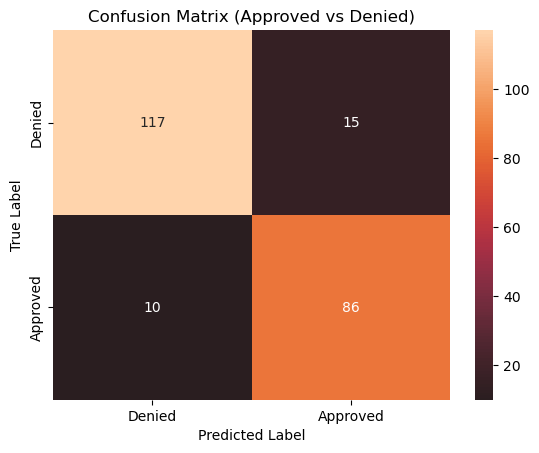

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Load dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"
data = pd.read_csv(url, header=None, sep=r"\s+")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# ----------------------------------------------------
# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=44, shuffle=True
)

# ----------------------------------------------------
# Gradient Boosting Model

model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=33
)

model.fit(X_train, y_train)

print('Train Score is : ', model.score(X_train, y_train))
print('Test Score is : ', model.score(X_test, y_test))
print('----------------------------------------------------')

# ----------------------------------------------------
# Prediction

y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)

print('Predicted Values are : ', y_pred[:10])
print('Prediction Probabilities are : ', y_pred_prob[:10])

# ----------------------------------------------------
# Confusion Matrix

CM = confusion_matrix(y_test, y_pred)
print('Confusion Matrix is : \n', CM)

tn, fp, fn, tp = CM.ravel()
print('False Positives:', fp)

# ----------------------------------------------------
# Draw confusion matrix with Approved / Denied labels

sns.heatmap(
    CM,
    annot=True,
    fmt="d",
    center=True,
    xticklabels=["Denied", "Approved"],   # Predicted labels
    yticklabels=["Denied", "Approved"]    # Actual labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Approved vs Denied)")
plt.show()

Dataset loaded successfully!
Dataset shape: (690, 15)

X_train shape: (552, 14)
X_test shape: (138, 14)

=== AdaBoost Classifier (Adaptive Boosting) ===



C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


✓ Model Training Completed!
AdaBoost Train Score: 0.9039855072463768
AdaBoost Test Score: 0.855072463768116
Number of Estimators: 50
Learning Rate: 1.0

Estimator Weights (First 10):
[1.88124116 0.9193857  0.7442601  0.39538096 0.23556947 0.33174565
 0.46786568 0.31436181 0.31710886 0.28081147]

Estimator Errors (First 10):
[0.13224638 0.28508308 0.32207328 0.40242262 0.44137847 0.41781594
 0.38512153 0.42205043 0.4213805  0.43025484]

Feature Importances:
   Feature  Importance
2       A3    0.176809
4       A5    0.169791
12     A13    0.151954
7       A8    0.145693
13     A14    0.127286
6       A7    0.079079
9      A10    0.065645
11     A12    0.036349
3       A4    0.025562
1       A2    0.021833
5       A6    0.000000
0       A1    0.000000
8       A9    0.000000
10     A11    0.000000

Predicted Values (First 10): [1 1 1 0 1 1 1 1 0 1]
Actual Values (First 10): [1 1 0 1 1 1 1 1 0 1]

Prediction Probabilities (First 10):
[[0.31263387 0.68736613]
 [0.41025331 0.58974669]
 [0.40

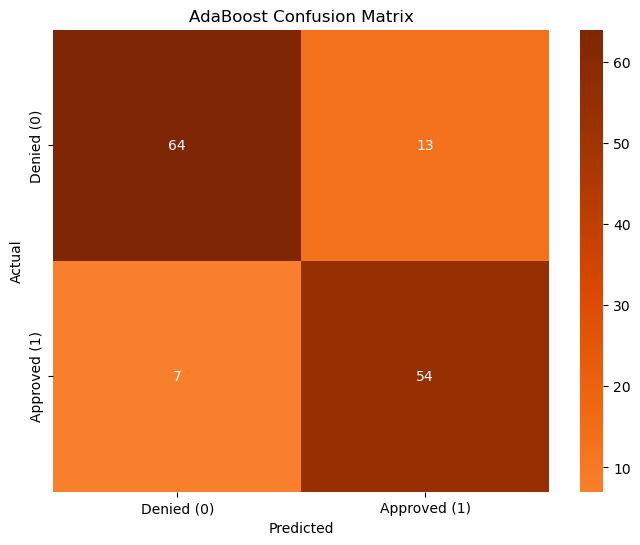


AdaBoost Accuracy Score: 0.8551
AdaBoost F1 Score: 0.8438

Classification Report:
              precision    recall  f1-score   support

      Denied       0.90      0.83      0.86        77
    Approved       0.81      0.89      0.84        61

    accuracy                           0.86       138
   macro avg       0.85      0.86      0.85       138
weighted avg       0.86      0.86      0.86       138



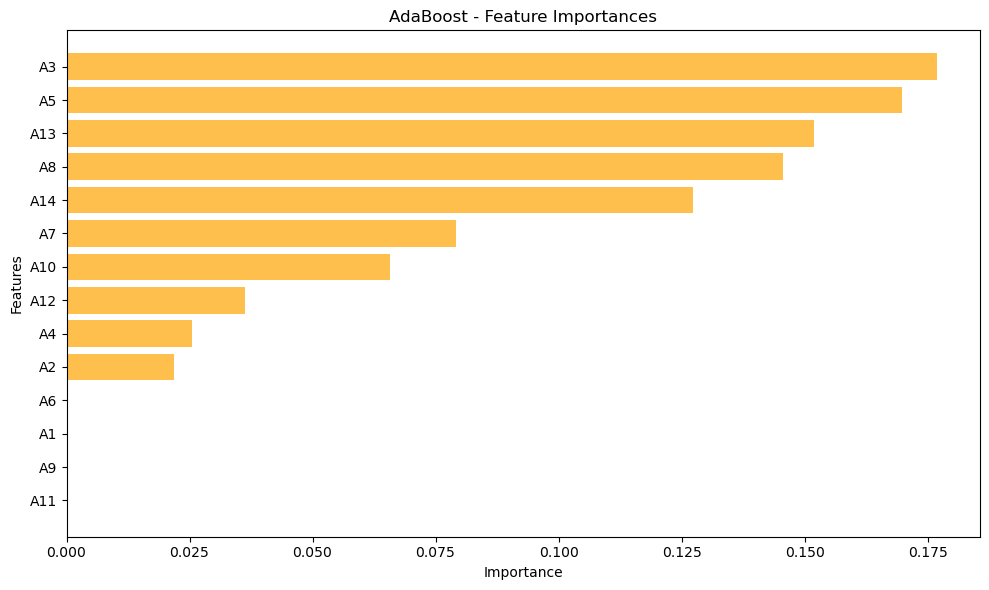


=== Testing Different Number of Estimators ===
n_estimators = 10: Test Accuracy = 0.8333
n_estimators = 25: Test Accuracy = 0.8478
n_estimators = 50: Test Accuracy = 0.8551
n_estimators = 75: Test Accuracy = 0.8551
n_estimators = 100: Test Accuracy = 0.8623


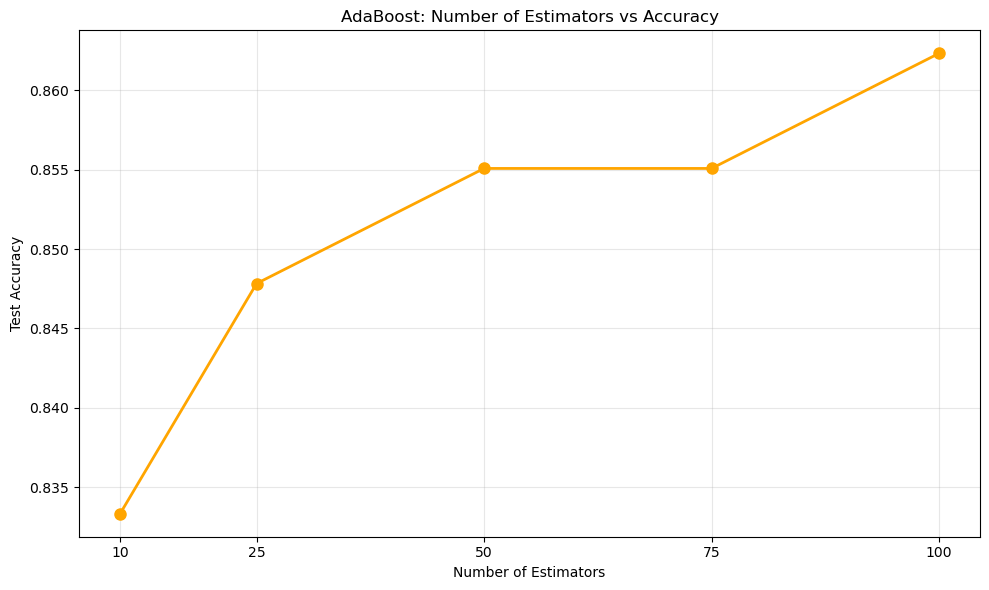


Best n_estimators: 100 with accuracy: 0.8623

✅ AdaBoost Analysis Complete!


In [7]:
# ============================================================
# ADABOOST - ADAPTIVE BOOSTING (FIXED FOR JUPYTER NOTEBOOK)
# Australian Credit Approval Dataset
# ============================================================

# Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# Load Dataset
# ============================================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"
column_names = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 
                'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'target']

data = pd.read_csv(url, sep=' ', names=column_names, na_values='?')

print('Dataset loaded successfully!')
print('Dataset shape:', data.shape)

# ============================================================
# Data Preprocessing
# ============================================================

X = data.drop('target', axis=1)
y = data['target']

# Handle missing values
X = X.fillna(X.median())

# Encode categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('\n====================================================')
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('====================================================')

# ============================================================
# AdaBoost Classifier (Adaptive Boosting) - CORRECTED
# ============================================================

print("\n=== AdaBoost Classifier (Adaptive Boosting) ===\n")

# Create AdaBoost Model (FIXED: estimator instead of base_estimator)
AdaBoostModel = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # CHANGED: estimator (not base_estimator)
    n_estimators=50,
    learning_rate=1.0,
    algorithm='SAMME',            # CHANGED: Use 'SAMME' for newer versions
    random_state=42
)

# Train the model
AdaBoostModel.fit(X_train, y_train)

# Model Details
print('✓ Model Training Completed!')
print('====================================================')
print('AdaBoost Train Score:', AdaBoostModel.score(X_train, y_train))
print('AdaBoost Test Score:', AdaBoostModel.score(X_test, y_test))
print('Number of Estimators:', AdaBoostModel.n_estimators)
print('Learning Rate:', AdaBoostModel.learning_rate)
print('====================================================')

# ============================================================
# Estimator Weights
# ============================================================

print('\nEstimator Weights (First 10):')
print(AdaBoostModel.estimator_weights_[:10])
print('\nEstimator Errors (First 10):')
print(AdaBoostModel.estimator_errors_[:10])

# ============================================================
# Feature Importances
# ============================================================

print('\nFeature Importances:')
feature_names = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 
                 'A9', 'A10', 'A11', 'A12', 'A13', 'A14']
importances = AdaBoostModel.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

# ============================================================
# Predictions
# ============================================================

y_pred = AdaBoostModel.predict(X_test)
y_pred_prob = AdaBoostModel.predict_proba(X_test)

print('\n====================================================')
print('Predicted Values (First 10):', y_pred[:10])
print('Actual Values (First 10):', y_test.values[:10])
print('\nPrediction Probabilities (First 10):')
print(y_pred_prob[:10])
print('====================================================')

# ============================================================
# Confusion Matrix
# ============================================================

CM = confusion_matrix(y_test, y_pred)
print('\n====================================================')
print('Confusion Matrix:\n', CM)
print('====================================================')

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(CM, annot=True, fmt='d', cmap='Oranges', center=True,
            xticklabels=['Denied (0)', 'Approved (1)'],
            yticklabels=['Denied (0)', 'Approved (1)'])
plt.title('AdaBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ============================================================
# Performance Metrics
# ============================================================

AccScore = accuracy_score(y_test, y_pred)
print('\nAdaBoost Accuracy Score:', round(AccScore, 4))

F1Score = f1_score(y_test, y_pred, average='binary')
print('AdaBoost F1 Score:', round(F1Score, 4))

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Denied', 'Approved']))

# ============================================================
# Plot Feature Importances
# ============================================================

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='orange', alpha=0.7)
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('AdaBoost - Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================
# Testing Different Number of Estimators
# ============================================================

print('\n====================================================')
print('=== Testing Different Number of Estimators ===')
print('====================================================')

n_estimators_list = [10, 25, 50, 75, 100]
scores = []

for n_est in n_estimators_list:
    ada_temp = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),  # FIXED
        n_estimators=n_est,
        learning_rate=1.0,
        random_state=42
    )
    ada_temp.fit(X_train, y_train)
    score = ada_temp.score(X_test, y_test)
    scores.append(score)
    print(f'n_estimators = {n_est}: Test Accuracy = {score:.4f}')

# Plot
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, scores, marker='o', linewidth=2, markersize=8, color='orange')
plt.xlabel('Number of Estimators')
plt.ylabel('Test Accuracy')
plt.title('AdaBoost: Number of Estimators vs Accuracy')
plt.grid(True, alpha=0.3)
plt.xticks(n_estimators_list)
plt.tight_layout()
plt.show()

print('\n====================================================')
print(f'Best n_estimators: {n_estimators_list[scores.index(max(scores))]} with accuracy: {max(scores):.4f}')
print('====================================================')

print('\n✅ AdaBoost Analysis Complete!')

Dataset loaded successfully!
Dataset shape: (690, 15)

Original Features: 14

=== Principal Component Analysis (PCA) ===

✓ PCA Transformation Completed!
Original number of features: 14
Reduced number of components: 13
Variance explained: 0.9725

Variance Explained by Each Component:
PC1: 0.1994 (19.94%)
PC2: 0.1065 (10.65%)
PC3: 0.0959 (9.59%)
PC4: 0.0791 (7.91%)
PC5: 0.0746 (7.46%)
PC6: 0.0710 (7.10%)
PC7: 0.0661 (6.61%)
PC8: 0.0589 (5.89%)
PC9: 0.0572 (5.72%)
PC10: 0.0479 (4.79%)
PC11: 0.0427 (4.27%)
PC12: 0.0382 (3.82%)
PC13: 0.0350 (3.50%)

Cumulative Variance Explained:
PC1 to PC1: 0.1994 (19.94%)
PC1 to PC2: 0.3059 (30.59%)
PC1 to PC3: 0.4018 (40.18%)
PC1 to PC4: 0.4809 (48.09%)
PC1 to PC5: 0.5555 (55.55%)
PC1 to PC6: 0.6265 (62.65%)
PC1 to PC7: 0.6926 (69.26%)
PC1 to PC8: 0.7515 (75.15%)
PC1 to PC9: 0.8087 (80.87%)
PC1 to PC10: 0.8566 (85.66%)
PC1 to PC11: 0.8993 (89.93%)
PC1 to PC12: 0.9375 (93.75%)
PC1 to PC13: 0.9725 (97.25%)


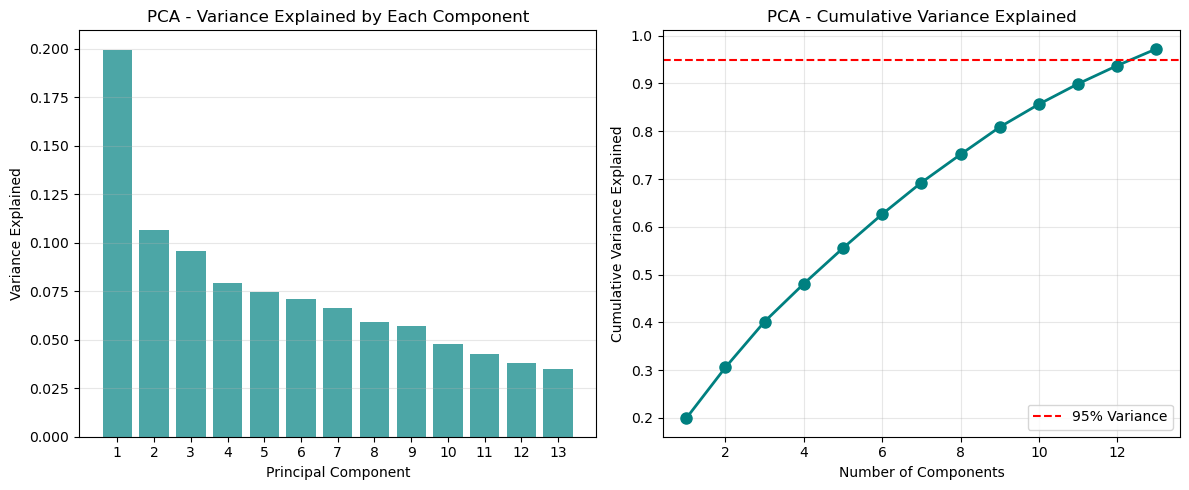


PCA Train shape: (552, 13)
PCA Test shape: (138, 13)

=== Random Forest with PCA ===

✓ Model Training Completed!
RF with PCA Train Score: 1.0
RF with PCA Test Score: 0.855072463768116

=== Comparison: Original Features vs PCA ===

Random Forest with ALL features (14):
  Train Score: 1.0
  Test Score: 0.8043478260869565

Random Forest with PCA (13 components):
  Train Score: 1.0
  Test Score: 0.855072463768116

Dimensionality Reduction: 14 → 13 features
Information Retained: 97.2%

Predicted Values (First 10): [1 1 0 1 1 0 0 1 0 1]
Actual Values (First 10): [1 1 0 1 1 1 1 1 0 1]

Prediction Probabilities (First 10):
[[0.09  0.91 ]
 [0.08  0.92 ]
 [0.5   0.5  ]
 [0.11  0.89 ]
 [0.15  0.85 ]
 [0.85  0.15 ]
 [0.62  0.38 ]
 [0.22  0.78 ]
 [0.817 0.183]
 [0.11  0.89 ]]

Confusion Matrix (PCA):
 [[63 14]
 [ 6 55]]


KeyError: "'Teals' is not a known colormap name"

<Figure size 800x600 with 0 Axes>

In [8]:
# ============================================================
# PCA (PRINCIPAL COMPONENT ANALYSIS) + RANDOM FOREST
# Australian Credit Approval Dataset
# ============================================================

# Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# Load Dataset
# ============================================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"
column_names = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 
                'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'target']

data = pd.read_csv(url, sep=' ', names=column_names, na_values='?')

print('Dataset loaded successfully!')
print('Dataset shape:', data.shape)

# ============================================================
# Data Preprocessing
# ============================================================

X = data.drop('target', axis=1)
y = data['target']

# Handle missing values
X = X.fillna(X.median())

# Encode categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Standardize features (CRITICAL FOR PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('\n====================================================')
print('Original Features:', X.shape[1])
print('====================================================')

# ============================================================
# PCA - Principal Component Analysis
# ============================================================

print("\n=== Principal Component Analysis (PCA) ===\n")

# Apply PCA to reduce dimensions
# Keep 95% of variance
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_pca = pca.fit_transform(X_scaled)

print('✓ PCA Transformation Completed!')
print('====================================================')
print('Original number of features:', X_scaled.shape[1])
print('Reduced number of components:', X_pca.shape[1])
print('Variance explained:', round(pca.explained_variance_ratio_.sum(), 4))
print('====================================================')

# Display variance explained by each component
print('\nVariance Explained by Each Component:')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'PC{i+1}: {var:.4f} ({var*100:.2f}%)')

print('\nCumulative Variance Explained:')
cumsum = np.cumsum(pca.explained_variance_ratio_)
for i, cum_var in enumerate(cumsum):
    print(f'PC1 to PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)')

# ============================================================
# Visualize Explained Variance
# ============================================================

# Plot 1: Individual Variance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_, 
        alpha=0.7, color='teal')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('PCA - Variance Explained by Each Component')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(axis='y', alpha=0.3)

# Plot 2: Cumulative Variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum) + 1), cumsum, 
         marker='o', linewidth=2, markersize=8, color='teal')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA - Cumulative Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# Train-Test Split with PCA Data
# ============================================================

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.20, random_state=42, stratify=y
)

print('\n====================================================')
print('PCA Train shape:', X_train_pca.shape)
print('PCA Test shape:', X_test_pca.shape)
print('====================================================')

# ============================================================
# Train Random Forest on PCA Data
# ============================================================

print("\n=== Random Forest with PCA ===\n")

# Train model on PCA-reduced data
RF_PCA_Model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

RF_PCA_Model.fit(X_train_pca, y_train)

print('✓ Model Training Completed!')
print('====================================================')
print('RF with PCA Train Score:', RF_PCA_Model.score(X_train_pca, y_train))
print('RF with PCA Test Score:', RF_PCA_Model.score(X_test_pca, y_test))
print('====================================================')

# ============================================================
# Compare: Original Features vs PCA
# ============================================================

print("\n=== Comparison: Original Features vs PCA ===\n")

# Train on original data for comparison
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

RF_Full_Model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

RF_Full_Model.fit(X_train_full, y_train_full)

print('Random Forest with ALL features (14):')
print('  Train Score:', RF_Full_Model.score(X_train_full, y_train_full))
print('  Test Score:', RF_Full_Model.score(X_test_full, y_test_full))

print(f'\nRandom Forest with PCA ({X_pca.shape[1]} components):')
print('  Train Score:', RF_PCA_Model.score(X_train_pca, y_train))
print('  Test Score:', RF_PCA_Model.score(X_test_pca, y_test))

print('\n====================================================')
print(f'Dimensionality Reduction: {X.shape[1]} → {X_pca.shape[1]} features')
print(f'Information Retained: {pca.explained_variance_ratio_.sum()*100:.1f}%')
print('====================================================')

# ============================================================
# Predictions
# ============================================================

y_pred_pca = RF_PCA_Model.predict(X_test_pca)
y_pred_prob_pca = RF_PCA_Model.predict_proba(X_test_pca)

print('\n====================================================')
print('Predicted Values (First 10):', y_pred_pca[:10])
print('Actual Values (First 10):', y_test.values[:10])
print('\nPrediction Probabilities (First 10):')
print(y_pred_prob_pca[:10])
print('====================================================')

# ============================================================
# Confusion Matrix
# ============================================================

CM = confusion_matrix(y_test, y_pred_pca)
print('\n====================================================')
print('Confusion Matrix (PCA):\n', CM)
print('====================================================')

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(CM, annot=True, fmt='d', cmap='Teals', center=True,
            xticklabels=['Denied (0)', 'Approved (1)'],
            yticklabels=['Denied (0)', 'Approved (1)'])
plt.title('Random Forest with PCA - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ============================================================
# Performance Metrics
# ============================================================

AccScore = accuracy_score(y_test, y_pred_pca)
print('\nPCA + Random Forest Accuracy:', round(AccScore, 4))

F1Score = f1_score(y_test, y_pred_pca, average='binary')
print('PCA + Random Forest F1 Score:', round(F1Score, 4))

print('\nClassification Report (PCA):')
print(classification_report(y_test, y_pred_pca, target_names=['Denied', 'Approved']))

# ============================================================
# 2D Visualization using First 2 Principal Components
# ============================================================

print("\n=== 2D Visualization of PCA ===\n")

# Apply PCA with only 2 components for visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

print(f'Variance explained by 2 components: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%')

# Plot
plt.figure(figsize=(12, 5))

# Plot 1: Original classes
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis', alpha=0.6, edgecolors='k')
plt.colorbar(scatter1, label='Class')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA: First 2 Components (Actual Classes)')
plt.grid(True, alpha=0.3)

# Plot 2: Predictions
# Train model on 2D PCA data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.20, random_state=42, stratify=y
)

RF_2D = RandomForestClassifier(n_estimators=100, random_state=42)
RF_2D.fit(X_train_2d, y_train_2d)
y_pred_2d = RF_2D.predict(X_2d)

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_pred_2d, cmap='viridis', alpha=0.6, edgecolors='k')
plt.colorbar(scatter2, label='Predicted Class')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA: First 2 Components (Predictions)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Accuracy with only 2 PCA components: {RF_2D.score(X_test_2d, y_test_2d):.4f}')

# ============================================================
# Testing Different Number of Components
# ============================================================

print("\n=== Testing Different Number of Components ===\n")

n_components_list = [2, 4, 6, 8, 10, 12, 14]
pca_scores = []

for n_comp in n_components_list:
    # Apply PCA
    pca_temp = PCA(n_components=n_comp)
    X_temp = pca_temp.fit_transform(X_scaled)
    
    # Split data
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X_temp, y, test_size=0.20, random_state=42, stratify=y
    )
    
    # Train model
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train_temp, y_train_temp)
    
    score = rf_temp.score(X_test_temp, y_test_temp)
    variance = pca_temp.explained_variance_ratio_.sum()
    pca_scores.append((score, variance))
    
    print(f'Components: {n_comp:2d} | Accuracy: {score:.4f} | Variance: {variance*100:.1f}%')

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

scores = [s[0] for s in pca_scores]
variances = [s[1] for s in pca_scores]

ax1.plot(n_components_list, scores, marker='o', linewidth=2, 
         markersize=8, color='teal', label='Accuracy')
ax1.set_xlabel('Number of PCA Components')
ax1.set_ylabel('Accuracy', color='teal')
ax1.tick_params(axis='y', labelcolor='teal')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(n_components_list, variances, marker='s', linewidth=2, 
         markersize=8, color='orange', label='Variance Explained')
ax2.set_ylabel('Variance Explained', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('PCA: Number of Components vs Performance')
fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.85))
plt.tight_layout()
plt.show()

# ============================================================
# PCA Loadings (Feature Contributions)
# ============================================================

print("\n=== PCA Loadings (Feature Contributions) ===\n")

# Get loadings for first 3 components
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loading_df = pd.DataFrame(
    loadings[:, :3],
    columns=['PC1', 'PC2', 'PC3'],
    index=feature_names
)

print(loading_df)

# Visualize loadings
plt.figure(figsize=(12, 6))
sns.heatmap(loading_df, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('PCA Loadings: Feature Contributions to Principal Components')
plt.tight_layout()
plt.show()

print('\n✅ PCA Analysis Complete!')